<div style="position:relative; width:100%; height:100px;">
  <img src="https://raw.githubusercontent.com/stefanlessmann/VHB_ProDoc_ML/master/banner-nb.png" style="width:100%; object-fit:cover;" alt="ProDok-MachineLearning-Banner">
  <div style="
      position:absolute;
      left:4%;
      top:50%;
      transform:translateY(-50%);
      font-size:3.2vw;
      font-weight:750;
      color:#1f2a44;">
    ProDok – Machine Learning
  </div>
</div>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/stefanlessmann/VHB_ProDoc_ML/blob/master/P.II.1.nlp_senti.ipynb)

# P.II.1 Natural Language Processing and Sentiment Analysis 
The practice sessions complement the lectures and provide hands-on experience with the concepts covered in the course.
This session focuses on natural language processing (NLP). It introduces some popular NLP libraries and demonstrates their use. To that end, we consider a specific form of text classification, namely sentiment analysis, as our NLP application. 

As in the previous practice session, the available time does not permit manual coding or extensive code reviews. We will provide coding demos for selected parts and otherwise rely on LLMs to generate the codes we need. 


## Preliminaries
We recommend that you run this notebook in Google Colab, because we will use some libraries that may not be installed by default on your machine. The notebook also contains some code cells that install libraries that not even Colab provides by default. Do not execute these cell on your notebook, unless you have experience with Python environments and know what you are doing. Just use Colab to be on the safe side. 

In [1]:
# ============================================================
# Core scientific stack
# ============================================================
import os
import numpy as np
import pandas as pd
import subprocess
import sys
import matplotlib.pyplot as plt
RANDOM_STATE = 1803
np.random.seed(RANDOM_STATE)

# ============================================================
# Dataset loading (raw IMDB reviews)
# ============================================================
from datasets import load_dataset

# ============================================================
# Text cleaning
# ============================================================
import re
from bs4 import BeautifulSoup  # HTML removal
import lxml

import spacy
try:
    spacy.load("en_core_web_sm")
except OSError:
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])


# ============================================================
# sklearn utilities for vectorization, modeling, and evaluation
# ============================================================
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

# ============================================================
# Dictionary-based sentiment analysis (lexicon baseline)
# ============================================================
# Check and install vaderSentiment if needed
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "vaderSentiment"])


# ============================================================
# Hugging Face sentiment pipeline (Transformer-based)
# ============================================================
from transformers import pipeline


# ============================================================
# Supress Hugging Face warnings 
# ============================================================
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'


# IMDB Movie Review Dataset
We use a popular dataset for sentiment analysis, the IMDB movie review dataset. It contains 50,000 movie reviews, labeled as positive or negative. The dataset is available through the Hugging Face `datasets` library, which provides an easy interface to load and work with it.

In [ ]:
# ----------------------------
# Load data: Raw IMDB reviews
# ----------------------------
ds = load_dataset("imdb")

# Hugging Face datasets provide pre-defined train/test splits
train_text = ds["train"]["text"]
train_y = np.array(ds["train"]["label"], dtype=int)

test_text = ds["test"]["text"]
test_y = np.array(ds["test"]["label"], dtype=int)

print("Train:", len(train_text), "Test:", len(test_text))
print("Label distribution (train):", np.bincount(train_y))
print("Label distribution (test): ", np.bincount(test_y))


Train: 25000 Test: 25000
Label distribution (train): [12500 12500]
Label distribution (test):  [12500 12500]


In [9]:

# Inspect a couple of samples
examples = [888] 
for j in examples:
    print(train_text[j])
    print("label:", train_y[j])

John Candy. Need we say more? He is the main reason you should see this film. Most people don't realize how gifted he was as an actor. Witness him changing from poor slob to horny jerk. Just a simple(subtle) facial change and off we go. There are many great bits in this movie and many really dumb bits. The best moments for me are the KUNG FU U scenes as well as the great moment when John(in a trance) goes up on stage and talks about how much he loves his girlfriend-that is how much he and his genitals love his girlfriend. I'm sure reading this you might think this sequence sounds really crude. It is, but it is also very funny mainly because it is John Candy doing this bit. The story in general is pretty lame and Eugene Levy and Joe Flaherty(both SCTV alumni with Candy) are not given enough to do in the film. Levy has his moments, especially filming the wedding at the end(think Rod Serling) and the great scene when he is talking to his mother on the phone. Overall a good movie if you ha

# Traditional NLP Pipeline for Text Cleaning
Before we can apply any machine learning model to the text data, we need to preprocess it. This typically involves cleaning the text, which can include steps like lowercasing, removing punctuation, and eliminating stop words. We demonstrate these steps below, mainly for the sake of illustration. Most of the sentiment analysis approaches we will look at later would not require us to *clean the text manually*. 

In [ ]:
# ----------------------------
# Traditional text cleaning illustration
# ----------------------------
nlp = spacy.load("en_core_web_sm")  # english stopwords; also needed for later tokenization
stop_words = nlp.Defaults.stop_words
HTML_PARSER = "lxml"  # if not installed, BeautifulSoup falls back; install lxml for speed/robustness

_whitespace_re = re.compile(r"\s+")
_nonword_re = re.compile(r"[^a-zA-Z0-9\s]")  # keep letters/numbers/spaces

def strip_html(text: str) -> str:
    # IMDB contains lots of <br /> tags etc.
    return BeautifulSoup(text, HTML_PARSER).get_text(" ")

def remove_stopwords(text: str) -> str:
    """Remove stopwords from normalized text."""
    return ' '.join([word for word in text.split() if word not in stop_words])

def basic_normalize(text: str) -> str:
    text = text.lower()
    text = _nonword_re.sub(" ", text)
    text = _whitespace_re.sub(" ", text).strip()
    return text

def clean_text(text: str) -> str:
    text = strip_html(text)
    text = basic_normalize(text)
    text = remove_stopwords(text)  # Add this line
    return text
    

# Demo on a few examples
for j in examples:
    raw = train_text[j]
    cleaned = clean_text(raw)
    print("\n--- CLEANING DEMO", j, "---")
    print("RAW:    ", raw[:250].replace("\n", " "))
    print("CLEANED:", cleaned[:250])


--- CLEANING DEMO 888 ---
RAW:     John Candy. Need we say more? He is the main reason you should see this film. Most people don't realize how gifted he was as an actor. Witness him changing from poor slob to horny jerk. Just a simple(subtle) facial change and off we go. There are man
CLEANED: john candy need main reason film people don t realize gifted actor witness changing poor slob horny jerk simple subtle facial change great bits movie dumb bits best moments kung fu u scenes great moment john trance goes stage talks loves girlfriend g

--- CLEANING DEMO 18 ---
RAW:     I think I will make a movie next weekend. Oh wait, I'm working..oh I'm sure I can fit it in. It looks like whoever made this film fit it in. I hope the makers of this crap have day jobs because this film sucked!!! It looks like someones home movie an
CLEANED: think movie weekend oh wait m working oh m sure fit looks like film fit hope makers crap day jobs film sucked looks like someones home movie don t think 100 s

In [ ]:
# Apply cleaning (sub-sample for speed)
SUBSAMPLE_TRAIN = 10000  #  (None for full dataset)
SUBSAMPLE_TEST = 1000   #  (None for full dataset)

if SUBSAMPLE_TRAIN is not None:
    idx = np.random.RandomState(RANDOM_STATE).choice(len(train_text), size=SUBSAMPLE_TRAIN, replace=False)
    train_text_sub = [train_text[i] for i in idx]
    train_y_sub = train_y[idx]
else:
    train_text_sub = list(train_text)
    train_y_sub = train_y

if SUBSAMPLE_TEST is not None:
    idx = np.random.RandomState(RANDOM_STATE + 1).choice(len(test_text), size=SUBSAMPLE_TEST, replace=False)
    test_text_sub = [test_text[i] for i in idx]
    test_y_sub = test_y[idx]
else:
    test_text_sub = list(test_text)
    test_y_sub = test_y

train_clean = [clean_text(t) for t in train_text_sub]
test_clean = [clean_text(t) for t in test_text_sub]

print("Cleaned train/test:", len(train_clean), len(test_clean))

Cleaned train/test: 10000 5000


## Illustration of the Bag-of-Words (BoW) Model
The BoW model is a simple and widely used approach for text representation. It represents a document as a vector of word counts, ignoring grammar and word order. Many years back, this used to be an NLP de facto standards, and can still provide meaningful results in some applications. However, the BoW model has severe limitations, as discussed in class. 



BoW demo vocab size: 51340


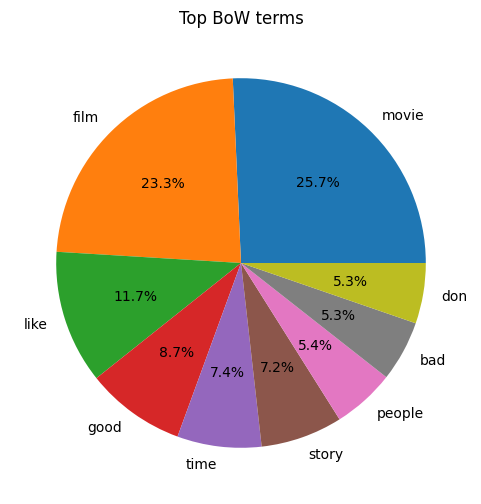

In [ ]:
bow_demo = CountVectorizer()

X_demo = bow_demo.fit_transform(train_clean)  
vocab_size = len(bow_demo.vocabulary_)
print("BoW demo vocab size:", vocab_size)

# Show the most frequent terms 
term_counts = np.asarray(X_demo.sum(axis=0)).ravel()
terms = np.array(bow_demo.get_feature_names_out())
top = np.argsort(-term_counts)[:9]

# show the top-10 terms as a piechart
plt.figure(figsize=(6, 6))
plt.pie(term_counts[top], labels=terms[top], autopct="%1.1f%%")
plt.title("Top BoW terms")
plt.show()


# Sentiment classification: positive vs. negative reviews
The core of the demo is on sentiment analsis, so let's proceed with exploring some algorithmic options; from simple to *overkill*

In [ ]:
# ----------------------------
# Helper function to assess alternative sentiment classifiers
# ----------------------------
def eval_binary(y_true, y_score, threshold=0.5, title="Model"):
    """
    Evaluate a binary classifier and visualize results.
    
    Computes AUC and accuracy metrics, prints a detailed classification report,
    and generates a ROC curve plot. This function is useful for comparing the
    performance of different sentiment classification models.
    
    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        True binary labels (typically 0 or 1).
    y_score : array-like of shape (n_samples,)
        Target scores or probability estimates for the positive class.
        Higher values indicate higher probability of positive sentiment.
    threshold : float, optional
        Decision threshold for converting scores to binary predictions.
        Default is 0.5 (scores >= threshold are classified as positive).
    title : str, optional
        Model name or description for display in plots and output.
        Default is "Model".
    
    Returns
    -------
    dict
        Dictionary containing:
        - 'auc': Area Under the ROC Curve (float in [0, 1])
        - 'acc': Accuracy score (float in [0, 1])
    
    Notes
    -----
    This function prints the AUC, accuracy, and a detailed classification report
    to the console, and displays a ROC curve plot.
    """
    auc = roc_auc_score(y_true, y_score)
    y_pred = (y_score >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    print(f"{title} | AUC={auc:.4f} | ACC={acc:.4f} | threshold={threshold}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

    fpr, tpr, _ = roc_curve(y_true, y_score)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC: {title} (AUC={auc:.3f})")
    plt.show()

    return {"auc": auc, "acc": acc}

# Dictionary-based sentiment analysis (VADER)
Dictionary-based sentiment analysis relies on predefined lexicons that assign sentiment scores to words or phrases. Dictionaries remain popular in many research fields. For example, the [LM Dictionary](https://sraf.nd.edu/loughranmcdonald-master-dictionary/) gained much popularity in finance and economics, where it is used to analyze the sentiment of financial news and reports. 

Since we work with movie reviews, we use a different dictionary in this demo, called VADER (Valence Aware Dictionary and sEntiment Reasoner). VADER provides a simple way to analyze the sentiment of text by summing the sentiment scores of individual words and applying some heuristics. It is particularly designed for social media text, which often contains slang, emoticons, and other informal language.

Lexicon baseline (VADER) | AUC=0.7796 | ACC=0.6792 | threshold=0.5

Classification report:
              precision    recall  f1-score   support

           0     0.7959    0.4820    0.6004      2500
           1     0.6285    0.8764    0.7320      2500

    accuracy                         0.6792      5000
   macro avg     0.7122    0.6792    0.6662      5000
weighted avg     0.7122    0.6792    0.6662      5000



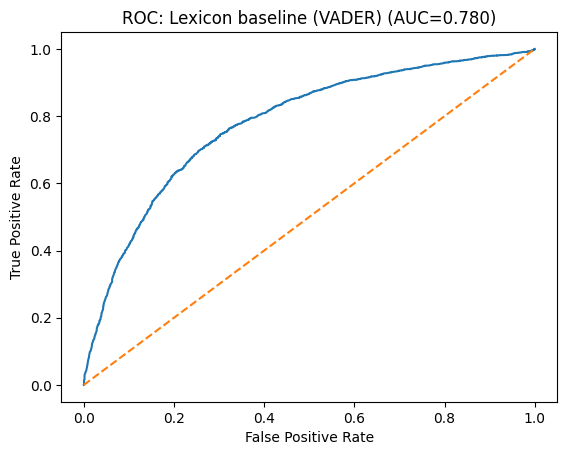

In [ ]:
# ----------------------------
# Dictionary-based sentiment analysis (VADER)
# ----------------------------
# VADER returns a "compound" score in [-1, 1].
# We'll convert to a [0, 1] score for AUC convenience.

vader = SentimentIntensityAnalyzer()
results = {}
def vader_score(text: str) -> float:
    s = vader.polarity_scores(text)["compound"]  # [-1, 1]
    return 0.5 * (s + 1.0)                       # map to [0, 1]

# Compute scores on cleaned text
vader_test_score = np.array([vader_score(t) for t in test_clean], dtype=float)

results["vader"] = eval_binary(test_y_sub, vader_test_score, threshold=0.5, title="Lexicon baseline (VADER)")

# Traditional ML-based sentiment classification
Sentiment analysis is a classification task. So we can use any of the classification algorithms we have covered in the course. We will use a simple linear classifier, namely logistic regression. However, we still need to convert the text data into a numerical format that the classifier can work with. A common approach is to use TF-IDF (Term Frequency-Inverse Document Frequency) features, which represent the importance of each word in a document relative to the entire corpus.

TF-IDF + L1 Logistic Regression | AUC=0.9243 | ACC=0.8428 | threshold=0.5

Classification report:
              precision    recall  f1-score   support

           0     0.8638    0.8140    0.8381      2500
           1     0.8241    0.8716    0.8472      2500

    accuracy                         0.8428      5000
   macro avg     0.8439    0.8428    0.8427      5000
weighted avg     0.8439    0.8428    0.8427      5000



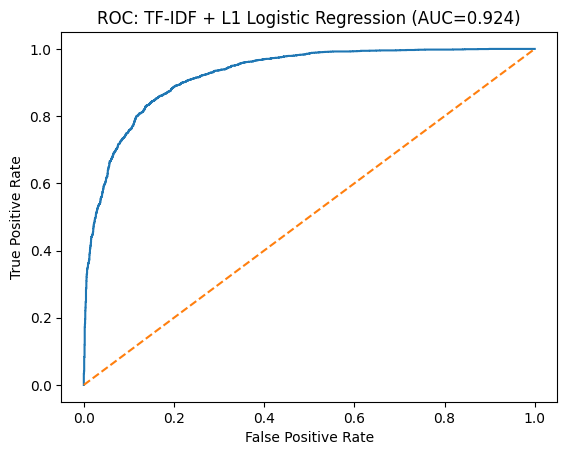

In [13]:
# ----------------------------
# 4) Traditional ML sentiment analysis: TF-IDF + L1 Logistic Regression (LASSO-style)
# ----------------------------
l1_logreg = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),      # use unigrams + bigrams -> often strong for sentiment classification
        min_df=2,
        max_df=0.9,
    )),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",  
        C=1.0,                   # smaller => stronger regularization
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

l1_logreg.fit(train_clean, train_y_sub)

# Predict probabilities for the positive class (label=1)
ml_test_score = l1_logreg.predict_proba(test_clean)[:, 1]
results["l1_logreg"] = eval_binary(test_y_sub, ml_test_score, threshold=0.5, title="TF-IDF + L1 Logistic Regression")

# Examining what the linear classifier has learnt
Linear classifiers are often considered "interpretable" because we can inspect their coefficients to understand which features contribute to the predictions. In the case of text classification with TF-IDF features, we can look at the coefficients associated with each word to see which words are most indicative of positive or negative sentiment.

In [ ]:
# Only works if the classifier exposes coef_ 

tfidf = l1_logreg.named_steps["tfidf"]
clf = l1_logreg.named_steps["clf"]
feature_names = tfidf.get_feature_names_out()
coef = clf.coef_.ravel()

top_pos = np.argsort(-coef)[:20]
top_neg = np.argsort(coef)[:20]

print("\nTop positive features:")
print(list(zip(feature_names[top_pos], coef[top_pos])))

print("\nTop negative features:")
print(list(zip(feature_names[top_neg], coef[top_neg])))


Top positive features:
[('years ago', np.float64(0.0)), ('years old', np.float64(0.0)), ('yes', np.float64(0.0)), ('young', np.float64(0.0)), ('young man', np.float64(0.0)), ('young people', np.float64(0.0)), ('younger', np.float64(0.0)), ('younger sister', np.float64(0.0)), ('writers', np.float64(0.0)), ('writing', np.float64(0.0)), ('written', np.float64(0.0)), ('wrong', np.float64(0.0)), ('yeah', np.float64(0.0)), ('year', np.float64(0.0)), ('year old', np.float64(0.0)), ('years', np.float64(0.0)), ('worst', np.float64(0.0)), ('worst film', np.float64(0.0)), ('worst movie', np.float64(0.0)), ('worth', np.float64(0.0))]

Top negative features:
[('years ago', np.float64(0.0)), ('years old', np.float64(0.0)), ('yes', np.float64(0.0)), ('young', np.float64(0.0)), ('young man', np.float64(0.0)), ('young people', np.float64(0.0)), ('younger', np.float64(0.0)), ('younger sister', np.float64(0.0)), ('writers', np.float64(0.0)), ('writing', np.float64(0.0)), ('written', np.float64(0.0)), ('

# Transformer-Based Sentiment Classifier
We identified the transformer architecture as the *goto* architecture for NLP tasks. We will next use a transformer-based model for sentiment classification. The easiest way to do this involves Hugging Face's `transformers` library, which provides pre-trained models and tools for fine-tuning them on specific tasks. However, we will not do any fine-tuning here, but rather use a pre-trained model directly for *zero-shot classification*. This means that we will simply ask the model to classify the sentiment of the reviews without any additional training on our specific dataset.

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

HF pipeline (DistilBERT SST-2) | AUC=0.9567 | ACC=0.9000 | threshold=0.5

Classification report:
              precision    recall  f1-score   support

           0     0.8621    0.9615    0.9091        26
           1     0.9524    0.8333    0.8889        24

    accuracy                         0.9000        50
   macro avg     0.9072    0.8974    0.8990        50
weighted avg     0.9054    0.9000    0.8994        50



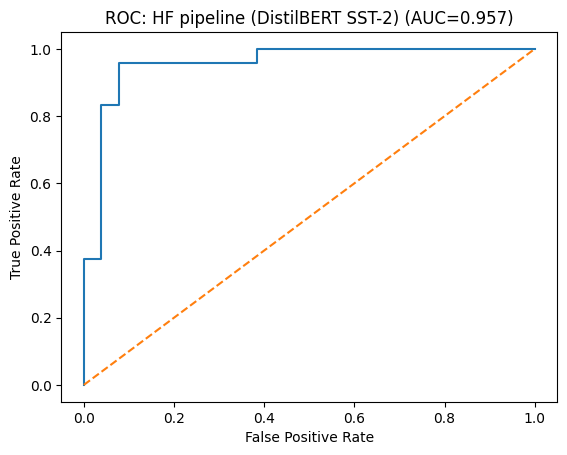

In [ ]:
# ----------------------------
# Hugging Face pipeline sentiment analysis 
# ----------------------------
# Default choice: SST-2 fine-tuned DistilBERT (binary).
hf = pipeline(
    task="sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    return_all_scores=False  
)

def hf_positive_score(output_scores) -> float:
    """
    output_scores: list of dicts like [{"label": "NEGATIVE", "score": ...}, {"label": "POSITIVE", "score": ...}]
    We return P(POSITIVE).
    """
    # Make it robust to ordering
    for d in output_scores:
        if d["label"].upper() == "POSITIVE":
            return float(d["score"])
    # fallback: if labels differ, return max score (shouldn't happen in SST-2 pipeline)
    return float(max(d["score"] for d in output_scores))

# The computations are complex. Sample reviews  to keep runtimes bearable
HF_MAX_EXAMPLES = 2000  # set to None for full test (can be slow)
hf_texts = test_text_sub if HF_MAX_EXAMPLES is None else test_text_sub[:HF_MAX_EXAMPLES]
hf_y = test_y_sub if HF_MAX_EXAMPLES is None else test_y_sub[:HF_MAX_EXAMPLES]

# IMPORTANT: Transformers have max sequence length; truncation keeps it simple
HF_BATCH_SIZE = 32 
hf_scores = []
for start in range(0, len(hf_texts), HF_BATCH_SIZE):
    batch = hf_texts[start:start + HF_BATCH_SIZE]
    out = hf(batch, truncation=True)
    # Now out is a list of single dicts like [{"label": "POSITIVE", "score": 0.95}, ...]
    hf_scores.extend([float(o["score"]) if o["label"] == "POSITIVE" else 1.0 - float(o["score"]) for o in out])

hf_scores = np.array(hf_scores, dtype=float)

results["hf_pipeline"] = eval_binary(hf_y, hf_scores, threshold=0.5, title="HF pipeline (DistilBERT SST-2)")

In [ ]:
# ----------------------------
# 6) Comparison summary
# ----------------------------
summary = (
    pd.DataFrame(results)
      .T.rename_axis("model")
      .reset_index()
      .sort_values(["auc", "acc"], ascending=False)
)

summary

,model,auc,acc
1,l1_logreg,0.924306,0.8428
0,vader,0.779601,0.6792


# ChatGPT for sentiment classification
We conclude the notebook with a minimal example of how to use ChatGPT for sentiment classification. We will use the OpenAI Python SDK to send prompts to the model and receive its responses. Note that the code **won't work on your machine** unless you have an OpenAI API key. 

In [22]:
from openai import OpenAI
mykey = os.getenv("OPENAI_API_KEY")  # here we access the API key from an environment variable
client = OpenAI(api_key=mykey)  # initialize the OpenAI client with the API key
dry_run=False  # set to True to skip actual API calls (to avoid costs when testing parts of the code 

# Define a prompt to classify one movie review
review = test_text[j]  # We reuse the example review from before
prompt = f"""
    Classify the sentiment of this movie review:
     ```review
      {review} 
    ```
    
"""

if not dry_run:
    # This is all we need to send the prompt to the model and get a response. The response object contains various metadata, but we just want the text output.
    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt
    )
    print("ChatGPT says:")
    print(response.output[0].content[0].text)

ChatGPT says:
The sentiment of this movie review is overwhelmingly negative. The reviewer expresses strong dislike for the movie, calling it "the worst movie I have ever seen" and comparing it unfavorably to notoriously bad films. The tone is sarcastic and mocking throughout.
